This notebook contains training and experimental code for an unused RF-DETR model (v1).

In [35]:
from rfdetr import RFDETRMedium
from rfdetr.assets.coco_classes import COCO_CLASSES
import torch
from pathlib import Path

In [36]:
# Check if CUDA is available and set device accordingly
if torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")
print(device)

cuda


In [ ]:
# Set paths
project_dir = Path.cwd().parent

In [ ]:
model = RFDETRMedium()

In [ ]:
model.train(dataset_dir=str(project_dir / 'data' / 'ChessmanDetection.v1-base-dataset-21-05-26.coco'),
            output_dir=str(project_dir / 'models' / 'rfdetr_medium'),
            epochs=20,
            batch_size=2,
            grad_accum_steps=8,
            lr=1e-4,
            device=device,
            resolution=640,
            checkpoint_interval=1,
            early_stopping=True,
            early_stopping_patience=3,
            early_stopping_min_delta=0.001,
            skip_best_epochs=3,
            lr_scheduler='step',
            eval_interval=1,
            log_per_class_metrics=True,
            compute_val_loss=True,
            compute_test_loss=True)

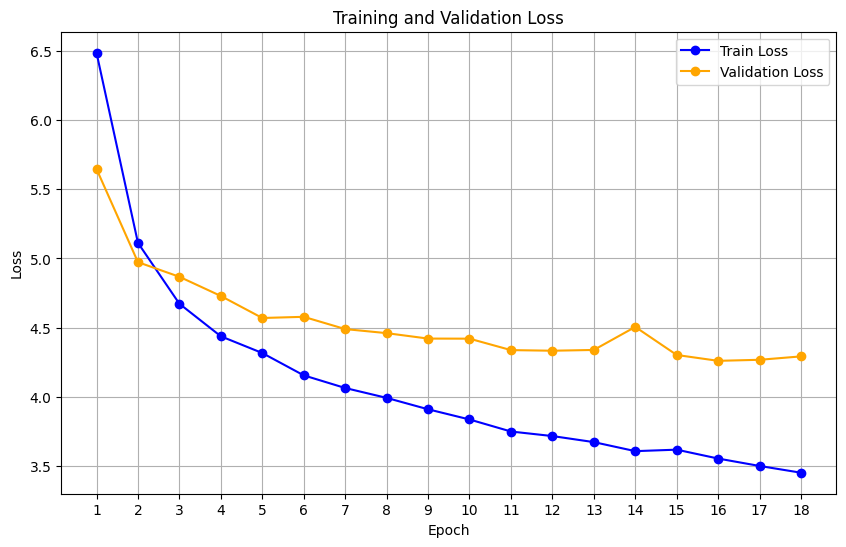

In [92]:
import pandas as pd
import matplotlib.pyplot as plt

metrics = pd.read_csv(project_dir / 'models' / 'rfdetr_medium' / 'metrics.csv')
epochs = (metrics['epoch'] + 1).drop_duplicates(keep='last').reset_index(drop=True)
train_losses = (metrics['train/loss']).dropna().reset_index(drop=True)
val_losses = (metrics['val/loss']).dropna().reset_index(drop=True)
plt.figure(figsize=(10, 6))
plt.plot(epochs, train_losses, label='Train Loss', color='blue', marker='o')
plt.plot(epochs, val_losses, label='Validation Loss', color='orange', marker='o')
plt.xticks(range(1, metrics['epoch'].max() + 2))
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend(loc='best')
plt.grid()
plt.show()

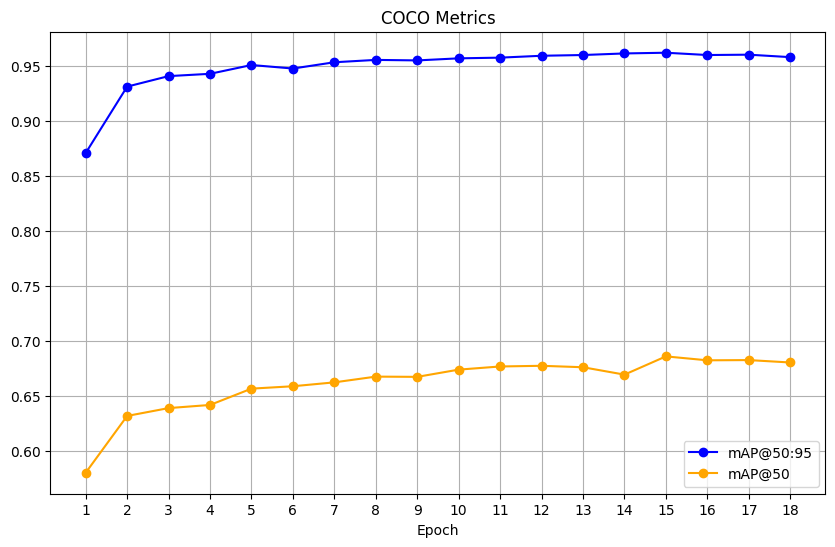

In [143]:
mAP = (metrics['val/mAP_50']).dropna().reset_index(drop=True)
mAP50 = (metrics['val/mAP_50_95']).dropna().reset_index(drop=True)
plt.figure(figsize=(10, 6))
plt.plot(epochs, mAP, label='mAP@50:95', color='blue', marker='o')
plt.plot(epochs, mAP50, label='mAP@50', color='orange', marker='o')
plt.xticks(range(1, metrics['epoch'].max() + 2))
plt.xlabel('Epoch')
plt.title('COCO Metrics')
plt.legend(loc='best')
plt.grid()
plt.show()

In [110]:
model = RFDETRMedium(pretrain_weights=str(project_dir / 'models' / 'rfdetr_medium' / 'checkpoint_best_total.pth'), num_classes=13)
label_list = ["", "B", "K", "N", "P", "Q", "R", "b", "k", "n", "p", "q", "r"]

[2026-05-31 13:53:07] [WARNING] rf-detr - Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
[2026-05-31 13:53:07] [WARNING] rf-detr - Using patch size 16 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
[2026-05-31 13:53:07] [WARNING] rf-detr - load_pretrain_weights: args.num_queries absent; inferred ckpt_num_queries=300 from tensor rows 3900 ÷ ckpt_group_detr=13.


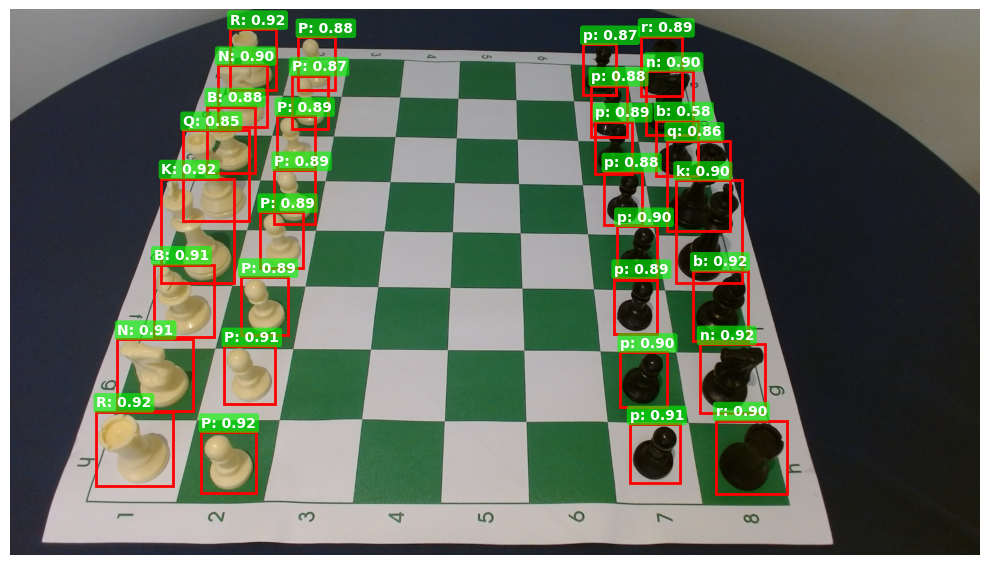

In [139]:
import cv2
import matplotlib.patches as patches
image_path = str(project_dir / "notebooks" / "game_opera_side" / "game_opera0.jpg")
image = cv2.imread(image_path)
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

predictions = model.predict(image_rgb, threshold=0.5)

fig, ax = plt.subplots(1, figsize=(10, 6))
ax.imshow(image_rgb)

for box, label, score in zip(predictions.xyxy, predictions.class_id, predictions.confidence):
    xmin, ymin, xmax, ymax = box
    width = xmax - xmin
    height = ymax - ymin
    
    rect = patches.Rectangle(
        (xmin, ymin), width, height, 
        linewidth=2, edgecolor='r', facecolor='none'
    )
    ax.add_patch(rect)
    
    text = f"{label_list[label]}: {score:.2f}"
    ax.text(
        xmin, ymin - 10, text, 
        color="white", fontsize=10, weight="bold",
        bbox=dict(facecolor="lime", alpha=0.6, edgecolor="none", boxstyle="round,pad=0.2")
    )

plt.axis("off")
plt.tight_layout()
plt.show()
